<a href="https://colab.research.google.com/github/monikabenavides/MaestriaUHE/blob/main/Actividad1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Portada del Notebook

**Nombre del Estudiante:** Mónica Benavides

**Módulo:** Big Data, Analyst & Data Scientist

**Docente:** Carlos Wladimir Carrillo Villavicencio

**Tema del Análisis:** Análisis de Datos de IRAG Fallecidos

**Fecha:** 26/06/2026

# Índice del Notebook

- [Introducción](#Introducción)
- [Carga y Exploración Inicial de Datos](#Carga-y-Exploración-Inicial-de-Datos)
- [Limpieza de Datos](#Limpieza-de-Datos)
- [Análisis Exploratorio de Datos (EDA)](#Análisis-Exploratorio-de-Datos-(EDA))
- [Visualización de Datos](#Visualización-de-Datos)
- [Machine Learning (ML)](#Machine-Learning-(ML))
- [Conclusiones](#Conclusiones)

# Introducción


### Descripción del Dataset
Este dataset contiene información sobre casos de Infección Respiratoria Aguda Grave (IRAG) fallecidos, proporcionando detalles demográficos, clínicos y de laboratorio de los pacientes. El objetivo principal de este análisis es comprender los factores asociados a la mortalidad por IRAG y extraer insights que puedan ayudar en la prevención y el manejo de futuros casos.

### Fuente
El archivo `irag_fallecidos.csv` ha sido cargado desde la ruta `/content/drive/MyDrive/Task1/irag_fallecidos.csv`.

### Variable Objetivo
Para este análisis, la variable objetivo podría ser determinada basándose en el campo `fallecido_si_no`. Identificaremos las columnas relevantes para predecir si un paciente fallece debido a IRAG.

# Carga y Exploración Inicial de Datos

In [125]:
import pandas as pd
import hashlib

In [183]:
import pandas as pd
import re

# Cargar el archivo especificando el separador correcto y la codificación adecuada
df = pd.read_csv('/content/drive/MyDrive/Task1/irag_fallecidos.csv', sep=';', encoding='latin1')



In [185]:
# Renombrar explícitamente la columna 'ï»¿cod_paciente' a 'cod_paciente'
if 'ï»¿cod_paciente' in df.columns:
    df.rename(columns={'ï»¿cod_paciente': 'cod_paciente'}, inplace=True)
print("Columnas del DataFrame después de renombrar:\n", df.columns.tolist())

Columnas del DataFrame después de renombrar:
 ['cod_paciente', 'fecha_caso_pac', 'unidad_operativa', 'tipo_atencion', 'fecha_hospitalizacion', 'nacionalidad', 'provincia', 'canton', 'sexo_pac', 'edad_pac', 'tipo_edad_pac', 'inicio_fiebre', 'semana_epi', 'comorbilidad', 'antecedente_viaje', 'embarazo', 'fecha_investigacion', 'condicion_final', 'fecha_fallecimiento', 'uci', 'ingreso_uci', 'egreso_uci', 'confirmado_por', 'fecha_cierre', 'tipo_muestra_laboratorio', 'fecha_toma_laboratorio', 'fecha_recepcion_laboratorio', 'muestra_adecuada', 'fecha_muestra_procesada', 'resultado_laboratorio', 'agente_epidemiologico']


In [186]:
print('### Primeras 5 filas del Dataset')
display(df.head())

### Primeras 5 filas del Dataset


,cod_paciente,fecha_caso_pac,unidad_operativa,tipo_atencion,fecha_hospitalizacion,nacionalidad,provincia,canton,sexo_pac,edad_pac,...,egreso_uci,confirmado_por,fecha_cierre,tipo_muestra_laboratorio,fecha_toma_laboratorio,fecha_recepcion_laboratorio,muestra_adecuada,fecha_muestra_procesada,resultado_laboratorio,agente_epidemiologico
0,58297,8/11/2023,HOSPITAL DE NIÃâOS BACA ORTIZ,hosptalizacion,7/11/2023,Ecuador,Sucumbios,Shushufindi,Femenino,1,...,8/11/2023,Laboratorio,10/11/2023,Hisopado Nasofar?ngeo,8/11/2023,8/11/2023,Si,8/11/2023,Negativo,Negativo
1,46486,26/1/2022,HOSPITAL DE NIÃâOS BACA ORTIZ,hosptalizacion,26/1/2022,Ecuador,Sucumbios,Lago Agrio,Femenino,1,...,27/1/2022,Laboratorio,2/2/2022,Hisopado Nasofar?ngeo,27/1/2022,28/1/2022,Si,28/1/2022,Positivo,SARS CoV2
2,54041,23/3/2023,HOSPITAL DE NIÃâOS BACA ORTIZ,hosptalizacion,22/3/2023,Ecuador,Sucumbios,Nueva Loja,Femenino,9,...,26/3/2023,Laboratorio,28/3/2023,Hisopado Nasofar?ngeo,23/3/2023,24/3/2023,Si,24/3/2023,Negativo,Negativo
3,53467,7/3/2023,HOSPITAL VICENTE CORRAL MOSCOSO,hosptalizacion,7/3/2023,Ecuador,Zamora Chinchipe,ZAMORA,Femenino,7,...,9/3/2023,Laboratorio,10/3/2023,Hisopado Nasofar?ngeo,7/3/2023,8/3/2023,Si,8/3/2023,Positivo,Influenza B
4,50084,3/10/2022,HOSPITAL VICENTE CORRAL MOSCOSO,hosptalizacion,3/10/2022,Ecuador,Morona Santiago,GUALAQUIZA EL PANGUI,Femenino,3,...,17/10/2022,Laboratorio,18/10/2022,Hisopado Nasofar?ngeo,3/10/2022,4/10/2022,Si,4/10/2022,Negativo,Negativo


In [187]:
print('### Tamaño del Dataset')
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.\n")

print('### Variables y Tipos de Datos')
df.info()

### Tamaño del Dataset
El dataset tiene 1584 filas y 31 columnas.

### Variables y Tipos de Datos
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1584 entries, 0 to 1583
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   cod_paciente                 1584 non-null   int64 
 1   fecha_caso_pac               1584 non-null   object
 2   unidad_operativa             1584 non-null   object
 3   tipo_atencion                1584 non-null   object
 4   fecha_hospitalizacion        1584 non-null   object
 5   nacionalidad                 1584 non-null   object
 6   provincia                    1584 non-null   object
 7   canton                       1584 non-null   object
 8   sexo_pac                     1584 non-null   object
 9   edad_pac                     1584 non-null   int64 
 10  tipo_edad_pac                1584 non-null   object
 11  inicio_fiebre                1584 non-null   obje

# Limpieza de Datos

### Detección y Eliminación de Duplicados

Procedemos a identificar y eliminar filas duplicadas en el dataset para asegurar la unicidad de los registros. Utilizaremos el `cod_paciente` para identificar duplicados.

In [206]:
import pandas as pd

# 0. Convertir columnas de fecha a formato datetime
df['fecha_caso_pac'] = pd.to_datetime(df['fecha_caso_pac'], dayfirst=True)

# 1. Corrección y estandarización de caracteres en columnas de texto

# General replacements for common encoding artifacts across all object columns
# These patterns are often results of mis-decoded UTF-8 characters when read as Latin-1.
# Example: 'Ñ' (U+00D1) in UTF-8 becomes C3 91. If read as latin1, C3 is 'Ã', 91 is ''.
# Subsequent misinterpretation can lead to complex sequences like 'ÃÂ\u0098' for 'Ñ'.
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str)
    df[col] = df[col].str.replace('ÃÂ\u0098', 'Ñ', regex=False) # For 'Ñ'
    df[col] = df[col].str.replace('ÃÂ¡', 'Á', regex=False) # For 'Á'
    df[col] = df[col].str.replace('ÃÂ©', 'É', regex=False) # For 'É'
    df[col] = df[col].str.replace('ÃÂ­', 'Í', regex=False) # For 'Í'
    df[col] = df[col].str.replace('ÃÂ³', 'Ó', regex=False) # For 'Ó'
    df[col] = df[col].str.replace('ÃÂº', 'Ú', regex=False) # For 'Ú'
    df[col] = df[col].str.replace('ÃÂ¼', 'Ü', regex=False) # For 'Ü'
    df[col] = df[col].str.replace('ÃÂ±', 'ñ', regex=False) # For 'ñ' (lowercase)
    df[col] = df[col].str.replace('ÃÂ', 'Í', regex=False) # Another observed pattern for 'Í'
    # Removed the problematic general replacement of '?' with 'Ñ'

# Specific replacements for 'tipo_muestra_laboratorio'
df['tipo_muestra_laboratorio'] = df['tipo_muestra_laboratorio'].str.replace('HISOPADO NASOFARÑNGEO', 'HISOPADO NASOFARINGEO', regex=False)
df['tipo_muestra_laboratorio'] = df['tipo_muestra_laboratorio'].str.replace('HISOPADO NASOFARÍNGEO', 'HISOPADO NASOFARINGEO', regex=False)
df['tipo_muestra_laboratorio'] = df['tipo_muestra_laboratorio'].str.replace('ASPIRADO NASOFARÍNGEO - TRAQUEAL', 'ASPIRADO NASOFARINGEO - TRAQUEAL', regex=False)
df['tipo_muestra_laboratorio'] = df['tipo_muestra_laboratorio'].str.replace('ASPIRADO NASOFARÑNGEO - TRAQUEAL', 'ASPIRADO NASOFARINGEO - TRAQUEAL', regex=False)

# Specific replacements for 'unidad_operativa'
df['unidad_operativa'] = df['unidad_operativa'].str.replace('HOSPITAL DE NIÑOS BACA ORTIZ', 'HOSPITAL DE NIÑOS BACA ORTIZ', regex=False)
df['unidad_operativa'] = df['unidad_operativa'].str.replace('HOSPITAL HOMERO CASTAÑER CRESPO', 'HOSPITAL HOMERO CASTAÑER CRESPO', regex=False)

# Specific replacements for 'tipo_edad_pac' to standardize to 'AÑOS' and 'DIAS'
# This handles variations like 'AA±OS', 'A?OS', 'D?AS', 'DÁ-AS', 'DÍAS'
df['tipo_edad_pac'] = df['tipo_edad_pac'].str.replace('AA±OS', 'AÑOS', regex=False)
df['tipo_edad_pac'] = df['tipo_edad_pac'].str.replace('D?AS', 'DIAS', regex=False)
df['tipo_edad_pac'] = df['tipo_edad_pac'].str.replace('DÁ-AS', 'DIAS', regex=False)
df['tipo_edad_pac'] = df['tipo_edad_pac'].str.replace('DÍAS', 'DIAS', regex=False)

# Estandarización de texto (MAYÚSCULAS y sin espacios) - Applied AFTER specific replacements
columnas_obj = df.select_dtypes(include=['object']).columns
for col in columnas_obj:
    df[col] = df[col].astype(str).str.upper().str.strip()

# 2. Homologación de edad (Moved after character cleaning)
def homologar_edad(row):
    edad = row['edad_pac']
    tipo = str(row['tipo_edad_pac']).upper()
    if 'MES' in tipo:
        return edad / 12
    elif 'DIA' in tipo:
        return edad / 365
    return edad

df['edad_homologada'] = df.apply(homologar_edad, axis=1)

# 4. Manejo de valores nulos en columnas críticas
df['embarazo'] = df['embarazo'].fillna('NO APLICA')
df['ingreso_uci'] = df['ingreso_uci'].fillna('NO')
df['egreso_uci'] = df['egreso_uci'].fillna('NO')

# 5. Detección y Eliminación de Duplicados
print('### Detección y Eliminación de Duplicados')
initial_rows = df.shape[0]
df.drop_duplicates(subset=['cod_paciente'], inplace=True)
duplicated_rows = initial_rows - df.shape[0]
print(f"Se han eliminado {duplicated_rows} filas duplicadas.\n")

print(f"El dataset tiene actualmente {df.shape[0]} filas y {df.shape[1]} columnas.")

print("\n--- Primeras 5 filas ---")
display(df[['fecha_caso_pac', 'edad_pac', 'tipo_edad_pac', 'edad_homologada', 'sexo_pac', 'comorbilidad', 'tipo_muestra_laboratorio', 'unidad_operativa']].head())

print("\n--- Últimas 5 filas ---")
display(df[['fecha_caso_pac', 'edad_pac', 'tipo_edad_pac', 'edad_homologada', 'sexo_pac', 'comorbilidad', 'tipo_muestra_laboratorio', 'unidad_operativa']].tail())

### Detección y Eliminación de Duplicados
Se han eliminado 0 filas duplicadas.

El dataset tiene actualmente 1584 filas y 32 columnas.

--- Primeras 5 filas ---


,fecha_caso_pac,edad_pac,tipo_edad_pac,edad_homologada,sexo_pac,comorbilidad,tipo_muestra_laboratorio,unidad_operativa
0,2023-11-08,1,AÑOS,1.000000,FEMENINO,SI,HISOPADO NASOFARINGEO,HOSPITAL DE NIÑOS BACA ORTIZ
1,2022-01-26,1,AÑOS,1.000000,FEMENINO,NO,HISOPADO NASOFARINGEO,HOSPITAL DE NIÑOS BACA ORTIZ
2,2023-03-23,9,AÑOS,9.000000,FEMENINO,NO,HISOPADO NASOFARINGEO,HOSPITAL DE NIÑOS BACA ORTIZ
3,2023-03-07,7,MESES,0.583333,FEMENINO,NO,HISOPADO NASOFARINGEO,HOSPITAL VICENTE CORRAL MOSCOSO
4,2022-10-03,3,MESES,0.250000,FEMENINO,NO,HISOPADO NASOFARINGEO,HOSPITAL VICENTE CORRAL MOSCOSO



--- Últimas 5 filas ---


,fecha_caso_pac,edad_pac,tipo_edad_pac,edad_homologada,sexo_pac,comorbilidad,tipo_muestra_laboratorio,unidad_operativa
1579,2023-10-04,15,AÑOS,15.000000,FEMENINO,SI,HISOPADO NASOFARINGEO,HOSPITAL DE NIÑOS BACA ORTIZ
1580,2023-10-25,4,MESES,0.333333,MASCULINO,NO,HISOPADO NASOFARINGEO,HOSPITAL DE NIÑOS BACA ORTIZ
1581,2023-11-15,5,MESES,0.416667,MASCULINO,SI,ASPIRADO NASOFARINGEO - TRAQUEAL,HOSPITAL DE NIÑOS BACA ORTIZ
1582,2023-11-27,80,AÑOS,80.000000,FEMENINO,NO,HISOPADO NASOFARINGEO,HOSPITAL HOMERO CASTAÑER CRESPO
1583,2023-12-19,8,MESES,0.666667,MASCULINO,SI,HISOPADO NASOFARINGEO,HOSPITAL DEL NIÑO DR.FRANCISCO ICAZA BUSTAMANTE


In [204]:
print('### Detección y Eliminación de Duplicados')
initial_rows = df.shape[0]
df.drop_duplicates(subset=['cod_paciente'], inplace=True)
duplicated_rows = initial_rows - df.shape[0]
print(f"Se han eliminado {duplicated_rows} filas duplicadas.\n")

### Detección y Eliminación de Duplicados
Se han eliminado 0 filas duplicadas.



# Análisis Exploratorio de Datos (EDA)

### Estadística Descriptiva de Variables Numéricas


,cod_paciente,fecha_caso_pac,edad_pac,semana_epi,edad_homologada
count,1584.000000,1584,1584.000000,1584.000000,1584.000000
mean,47669.800505,2022-01-29 09:13:38.181818112,52.893308,21.098485,52.423490
min,40960.000000,2021-01-01 00:00:00,1.000000,1.000000,0.057534
25%,43598.500000,2021-04-13 00:00:00,34.000000,11.000000,34.000000
50%,45477.000000,2021-08-12 12:00:00,61.000000,17.500000,61.000000
75%,51183.000000,2022-12-10 12:00:00,76.000000,29.000000,76.000000
max,59769.000000,2023-12-29 00:00:00,103.000000,53.000000,103.000000
std,5130.379870,NaN,28.879025,14.092929,29.665563



### Distribución de Variables Categóricas Principales


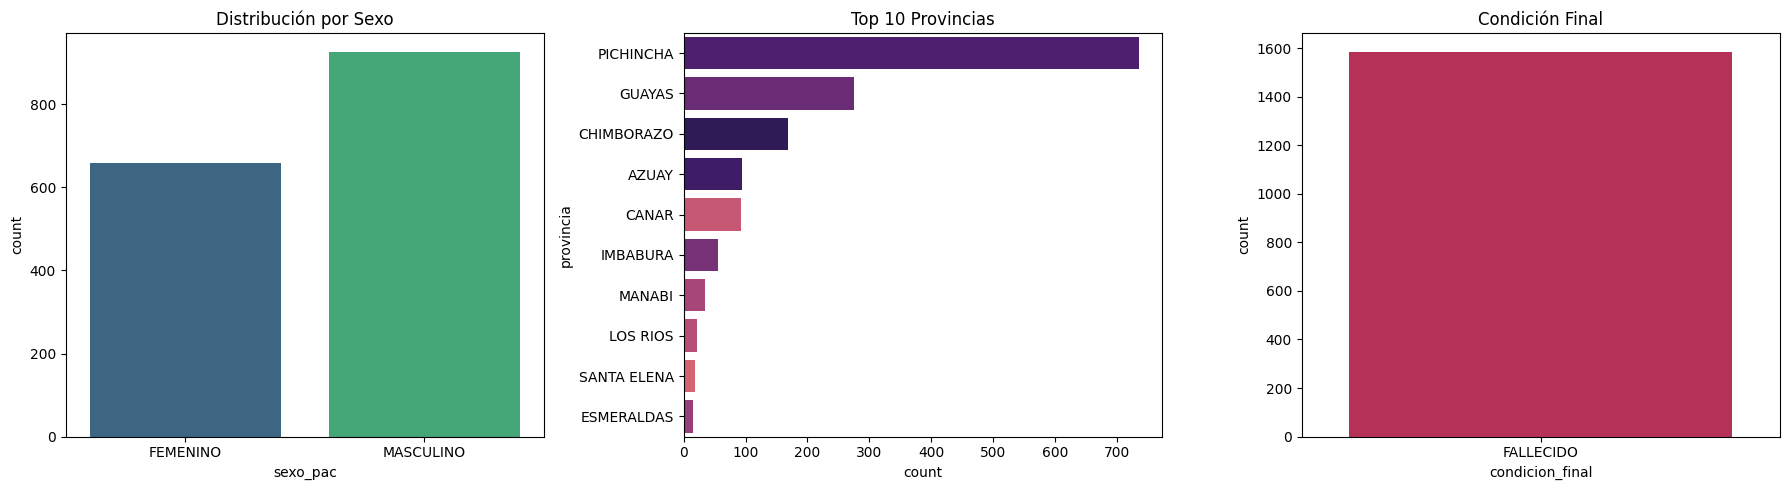


### Evolución Temporal de Casos


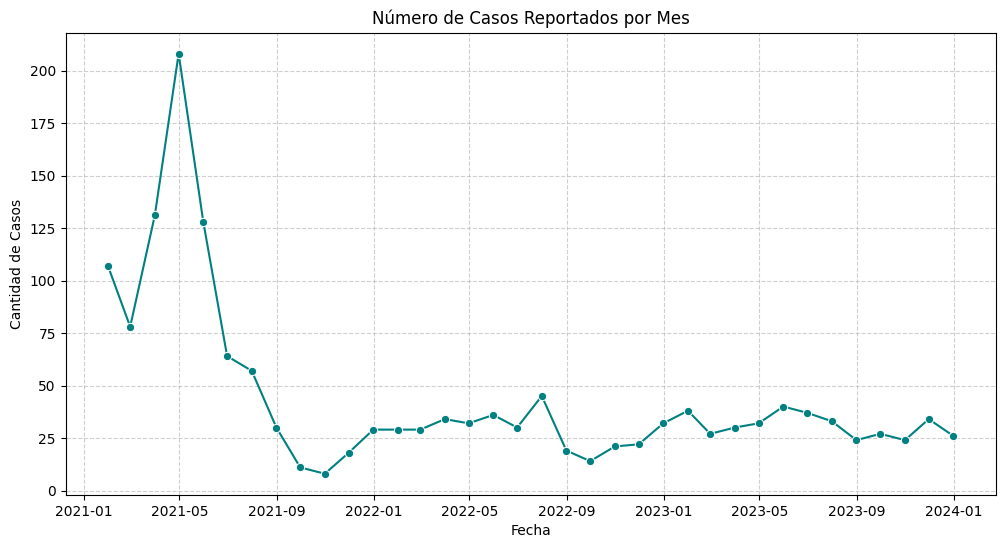

In [151]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Estadística Descriptiva
print("### Estadística Descriptiva de Variables Numéricas")
display(df.describe())

# 2. Análisis de Variables Categóricas
print("\n### Distribución de Variables Categóricas Principales")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x='sexo_pac', ax=axes[0], palette='viridis', hue='sexo_pac', legend=False)
axes[0].set_title('Distribución por Sexo')

sns.countplot(data=df, y='provincia', ax=axes[1], palette='magma', order=df['provincia'].value_counts().index[:10], hue='provincia', legend=False)
axes[1].set_title('Top 10 Provincias')

sns.countplot(data=df, x='condicion_final', ax=axes[2], palette='rocket', hue='condicion_final', legend=False)
axes[2].set_title('Condición Final')

plt.tight_layout()
plt.show()

# 3. Análisis de Variables Temporales
print("\n### Evolución Temporal de Casos")
# 'fecha_caso_pac' ya es un objeto datetime debido a la limpieza de datos
df_temp = df.set_index('fecha_caso_pac').resample('ME').size().reset_index(name='conteo')

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_temp, x='fecha_caso_pac', y='conteo', marker='o', color='teal')
plt.title('Número de Casos Reportados por Mes')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Casos')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Resumen de Variables Categóricas

Este resumen proporciona una visión general de las variables categóricas, mostrando la cantidad de valores únicos y las top 5 categorías con sus respectivas frecuencias para cada una. Esto nos ayuda a entender la distribución y la diversidad de los datos cualitativos.

In [205]:
import pandas as pd

print("### Resumen de Variables Categóricas\n")

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"--- Columna: '{col}' ---")
    print(f"Número de valores únicos: {df[col].nunique()}")
    print("Top 5 categorías:")
    display(df[col].value_counts().head().to_frame())
    print("\n")

### Resumen de Variables Categóricas

--- Columna: 'unidad_operativa' ---
Número de valores únicos: 18
Top 5 categorías:


,count
unidad_operativa,
HOSPITAL EUGENIO ESPEJO,345
HOSPITAL CARLOS ANDRADE MARIN (IESS),284
HOSPITAL GENERAL DOCENTE RIOBAMBA,167
HOSPITAL DEL NIÑO DR.FRANCISCO ICAZA BUSTAMANTE,161
HOSPITAL DE INFECTOLOGIA Y DERMATOLOGICO,146




--- Columna: 'tipo_atencion' ---
Número de valores únicos: 1
Top 5 categorías:


,count
tipo_atencion,
HOSPTALIZACION,1584




--- Columna: 'fecha_hospitalizacion' ---
Número de valores únicos: 714
Top 5 categorías:


...

,count
fecha_muestra_procesada,
20/4/2021,24
12/4/2021,20
13/4/2021,13
19/4/2021,12
9/3/2021,12




--- Columna: 'resultado_laboratorio' ---
Número de valores únicos: 2
Top 5 categorías:


,count
resultado_laboratorio,
NEGATIVO,930
POSITIVO,654




--- Columna: 'agente_epidemiologico' ---
Número de valores únicos: 9
Top 5 categorías:


,count
agente_epidemiologico,
NEGATIVO,930
SARS COV2,559
A/H1N1 2009,24
INFLUENZA B,20
VSR,19


### Análisis de Frecuencia de Categorías

In [207]:
print('### Análisis Completo de Frecuencia de Categorías por Variable\n')

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"--- Columna: '{col}' ---")
    display(df[col].value_counts().to_frame())
    print("\n")

### Análisis Completo de Frecuencia de Categorías por Variable

--- Columna: 'unidad_operativa' ---


,count
unidad_operativa,
HOSPITAL EUGENIO ESPEJO,345
HOSPITAL CARLOS ANDRADE MARIN (IESS),284
HOSPITAL GENERAL DOCENTE RIOBAMBA,167
HOSPITAL DEL NIÑO DR.FRANCISCO ICAZA BUSTAMANTE,161
HOSPITAL DE INFECTOLOGIA Y DERMATOLOGICO,146
HOSPITAL HOMERO CASTAÑER CRESPO,100
HOSPITAL VICENTE CORRAL MOSCOSO,99
HOSPITAL DE NIÑOS BACA ORTIZ,87
HOSPITAL DEL SUR ENRIQUE GARCES,83




--- Columna: 'tipo_atencion' ---


,count
tipo_atencion,
HOSPTALIZACION,1584




--- Columna: 'fecha_hospitalizacion' ---


...

,count
fecha_muestra_procesada,
20/4/2021,24
12/4/2021,20
13/4/2021,13
19/4/2021,12
9/3/2021,12
...,...
24/6/2022,1
15/7/2022,1
31/10/2022,1




--- Columna: 'resultado_laboratorio' ---


,count
resultado_laboratorio,
NEGATIVO,930
POSITIVO,654




--- Columna: 'agente_epidemiologico' ---


,count
agente_epidemiologico,
NEGATIVO,930
SARS COV2,559
A/H1N1 2009,24
INFLUENZA B,20
VSR,19
A/H3N2,16
OTROS,8
PARAINFLUENZA III,5
ADENOVIRUS,3


### Conteo de Valores Únicos por Variable

In [134]:
print('### Conteo de Variables Únicas por Columna\n')

for col in df.columns:
    print(f"--- Columna: '{col}' ---")
    print(f"Número de valores únicos: {df[col].nunique()}")
    print("\n")

### Conteo de Variables Únicas por Columna

--- Columna: 'cod_paciente' ---
Número de valores únicos: 1584


--- Columna: 'fecha_caso_pac' ---
Número de valores únicos: 685


--- Columna: 'unidad_operativa' ---
Número de valores únicos: 18


--- Columna: 'tipo_atencion' ---
Número de valores únicos: 1


--- Columna: 'fecha_hospitalizacion' ---
Número de valores únicos: 714


--- Columna: 'nacionalidad' ---
Número de valores únicos: 1


--- Columna: 'provincia' ---
Número de valores únicos: 23


--- Columna: 'canton' ---
Número de valores únicos: 150


--- Columna: 'sexo_pac' ---
Número de valores únicos: 2


--- Columna: 'edad_pac' ---
Número de valores únicos: 100


--- Columna: 'tipo_edad_pac' ---
Número de valores únicos: 5


--- Columna: 'inicio_fiebre' ---
Número de valores únicos: 719


--- Columna: 'semana_epi' ---
Número de valores únicos: 53


--- Columna: 'comorbilidad' ---
Número de valores únicos: 2


--- Columna: 'antecedente_viaje' ---
Número de valores únicos: 2


--- Co

### Ordenamiento de Datos para Identificación de Patrones y Extremos

In [196]:
print('### Pacientes con Menor Edad Homologada (Valores Extremos Inferiores)\n')
display(df.sort_values(by='edad_homologada', ascending=True).head())

print('\n### Pacientes con Mayor Edad Homologada (Valores Extremos Superiores)\n')
display(df.sort_values(by='edad_homologada', ascending=False).head())

### Pacientes con Menor Edad Homologada (Valores Extremos Inferiores)



,cod_paciente,fecha_caso_pac,unidad_operativa,tipo_atencion,fecha_hospitalizacion,nacionalidad,provincia,canton,sexo_pac,edad_pac,...,confirmado_por,fecha_cierre,tipo_muestra_laboratorio,fecha_toma_laboratorio,fecha_recepcion_laboratorio,muestra_adecuada,fecha_muestra_procesada,resultado_laboratorio,agente_epidemiologico,edad_homologada
50,58042,2023-10-25,HOSPITAL DE NIÃÂOS BACA ORTIZ,HOSPTALIZACION,24/10/2023,ECUADOR,PICHINCHA,QUITO,FEMENINO,1,...,LABORATORIO,5/1/2024,HISOPADO NASOFAR?NGEO,25/10/2023,26/10/2023,SI,26/10/2023,NEGATIVO,NEGATIVO,0.083333
1551,47492,2022-04-22,HOSPITAL DEL NIÃÂO DR.FRANCISCO ICAZA BUSTA...,HOSPTALIZACION,22/4/2022,ECUADOR,GUAYAS,GUAYAQUIL,MASCULINO,1,...,LABORATORIO,12/5/2022,HISOPADO NASOFAR?NGEO,22/4/2022,25/4/2022,SI,26/4/2022,NEGATIVO,NEGATIVO,0.083333
778,54620,2023-04-11,HOSPITAL DEL NIÃÂO DR.FRANCISCO ICAZA BUSTA...,HOSPTALIZACION,10/4/2023,ECUADOR,GUAYAS,GUAYAQUIL,FEMENINO,1,...,LABORATORIO,8/5/2023,HISOPADO NASOFAR?NGEO,11/4/2023,11/4/2023,SI,12/4/2023,NEGATIVO,NEGATIVO,0.083333
1536,46585,2022-02-07,HOSPITAL DEL NIÃÂO DR.FRANCISCO ICAZA BUSTA...,HOSPTALIZACION,6/2/2022,ECUADOR,GUAYAS,GUAYAQUIL,MASCULINO,1,...,LABORATORIO,19/2/2022,HISOPADO NASOFAR?NGEO,7/2/2022,7/2/2022,SI,8/2/2022,NEGATIVO,NEGATIVO,0.083333
1552,47541,2022-04-27,HOSPITAL DEL NIÃÂO DR.FRANCISCO ICAZA BUSTA...,HOSPTALIZACION,27/4/2022,ECUADOR,GUAYAS,PALESTINA,MASCULINO,1,...,LABORATORIO,6/6/2022,HISOPADO NASOFAR?NGEO,27/4/2022,29/4/2022,SI,3/5/2022,NEGATIVO,NEGATIVO,0.083333



### Pacientes con Mayor Edad Homologada (Valores Extremos Superiores)



,cod_paciente,fecha_caso_pac,unidad_operativa,tipo_atencion,fecha_hospitalizacion,nacionalidad,provincia,canton,sexo_pac,edad_pac,...,confirmado_por,fecha_cierre,tipo_muestra_laboratorio,fecha_toma_laboratorio,fecha_recepcion_laboratorio,muestra_adecuada,fecha_muestra_procesada,resultado_laboratorio,agente_epidemiologico,edad_homologada
1449,42700,2021-02-08,HOSPITAL HOMERO CASTAÃÂER CRESPO,HOSPTALIZACION,8/2/2021,ECUADOR,CANAR,AZOGUES,FEMENINO,103,...,LABORATORIO,23/9/2021,ASPIRADO NASOFARÃÂ­NGEO - TRAQUEAL,10/2/2021,11/2/2021,SI,11/2/2021,NEGATIVO,NEGATIVO,103.0
1099,44506,2021-05-28,HOSPITAL GENERAL DOCENTE RIOBAMBA,HOSPTALIZACION,28/5/2021,ECUADOR,CHIMBORAZO,RIOBAMBA,FEMENINO,103,...,LABORATORIO,9/6/2021,HISOPADO NASOFAR?NGEO,28/5/2021,31/5/2021,SI,1/6/2021,POSITIVO,SARS COV2,103.0
1338,44836,2021-05-10,HOSPITAL HOMERO CASTAÃÂER CRESPO,HOSPTALIZACION,8/5/2021,ECUADOR,CANAR,AZOGUES,MASCULINO,99,...,LABORATORIO,23/9/2021,HISOPADO NASOFAR?NGEO,8/5/2021,12/5/2021,SI,12/5/2021,NEGATIVO,NEGATIVO,99.0
1363,44847,2021-05-26,HOSPITAL HOMERO CASTAÃÂER CRESPO,HOSPTALIZACION,26/5/2021,ECUADOR,CANAR,AZOGUES,FEMENINO,98,...,LABORATORIO,23/9/2021,HISOPADO NASOFAR?NGEO,26/5/2021,26/5/2021,SI,26/7/2021,NEGATIVO,NEGATIVO,98.0
466,43552,2021-04-12,HOSPITAL CARLOS ANDRADE MARIN (IESS),HOSPTALIZACION,11/4/2021,ECUADOR,PICHINCHA,QUITO,FEMENINO,98,...,LABORATORIO,24/4/2021,HISOPADO NASOFAR?NGEO,12/4/2021,12/4/2021,SI,12/4/2021,NEGATIVO,NEGATIVO,98.0


### Análisis de Correlación entre Edad Homologada y Variables Numéricas

Realizaremos un mapa de calor para visualizar la correlación entre la `edad_homologada` y otras variables numéricas presentes en el dataset. Esto nos ayudará a identificar relaciones lineales y posibles factores influyentes.

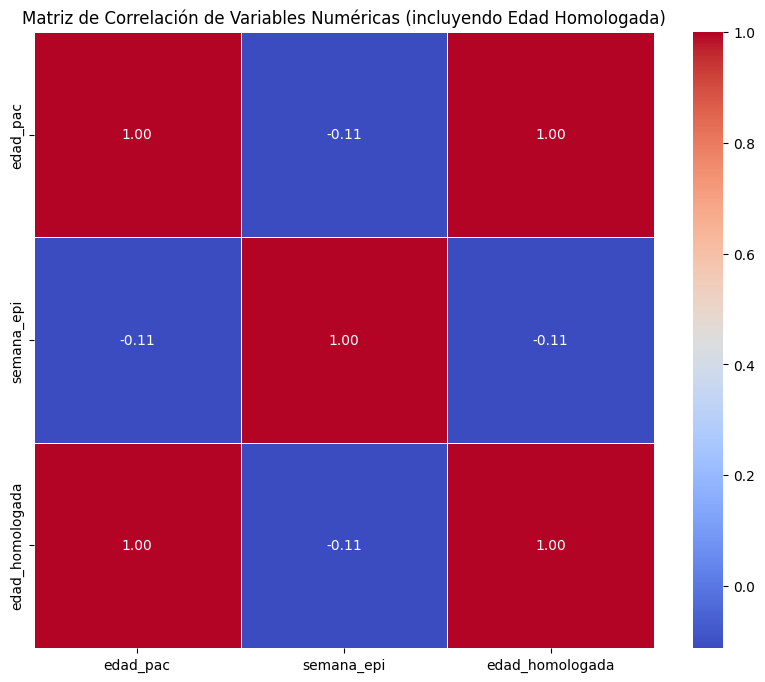


--- Correlación de 'edad_homologada' con otras variables --- 


,edad_homologada
edad_homologada,1.000000
edad_pac,0.998892
semana_epi,-0.112129


In [136]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar solo columnas numéricas para el análisis de correlación
# Excluir 'cod_paciente' ya que es un identificador y no una medida cuantitativa para correlación
numerical_cols = df.select_dtypes(include=['int64', 'float64']).drop(columns=['cod_paciente'], errors='ignore')

# Calcular la matriz de correlación
corr_matrix = numerical_cols.corr()

# Visualizar la matriz de correlación usando un mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Variables Numéricas (incluyendo Edad Homologada)')
plt.show()

print("\n--- Correlación de 'edad_homologada' con otras variables --- ")
display(corr_matrix['edad_homologada'].sort_values(ascending=False))

### Gráfico de Dispersión: Edad Homologada vs. Semana Epidemiológica

Este gráfico nos ayudará a visualizar la distribución de los casos en función de la edad del paciente y la semana epidemiológica, permitiendo identificar posibles patrones o agrupaciones.

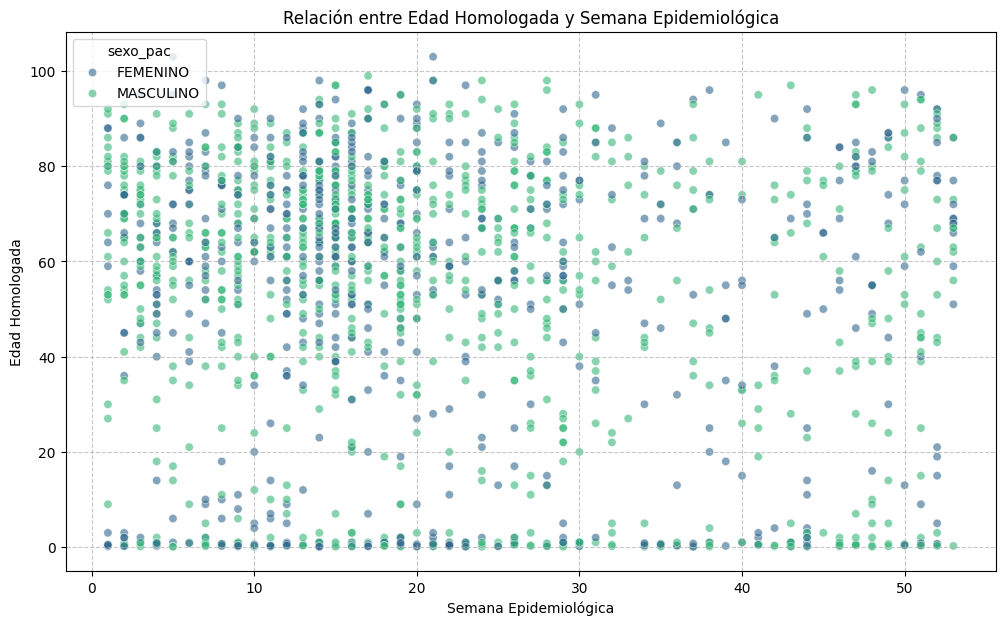

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='semana_epi', y='edad_homologada', alpha=0.6, hue='sexo_pac', palette='viridis')
plt.title('Relación entre Edad Homologada y Semana Epidemiológica')
plt.xlabel('Semana Epidemiológica')
plt.ylabel('Edad Homologada')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Análisis de Valores Atípicos en 'edad_pac' mediante Boxplot

Un boxplot es una herramienta excelente para visualizar la distribución de una variable numérica e identificar la presencia de valores atípicos (outliers). Analizaremos la columna `edad_pac` para detectar cualquier edad que se desvíe significativamente de la mayoría.

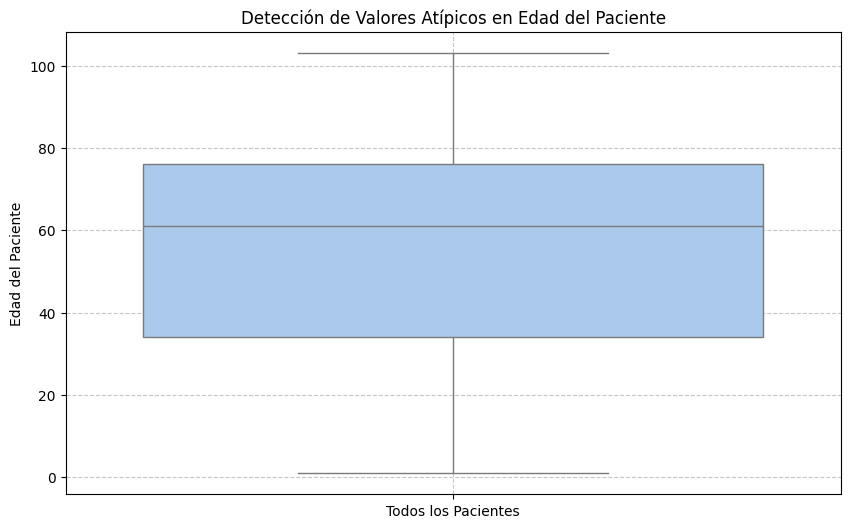

In [138]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.figure(figsize=(10, 6))
# Crear una variable x ficticia para el boxplot para satisfacer la advertencia
x_constant = pd.Series('Todos los Pacientes', index=df.index)
sns.boxplot(x=x_constant, y=df['edad_pac'], palette='pastel', hue=x_constant, legend=False)
plt.title('Detección de Valores Atípicos en Edad del Paciente')
plt.ylabel('Edad del Paciente')
plt.xlabel('') # Eliminar la etiqueta del eje x ya que es una constante ficticia
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Análisis de Valores Nulos Restantes

Después de las etapas de limpieza, es crucial verificar si aún quedan valores nulos en el dataset y en qué columnas. Esto nos permitirá decidir si se requiere una imputación adicional o si las columnas con muchos nulos deben ser consideradas para su exclusión en análisis futuros.

In [139]:
import pandas as pd

# Calcular el porcentaje de valores nulos por columna
null_percentage = df.isnull().sum() / len(df) * 100

# Filtrar solo las columnas que tienen valores nulos y ordenar
null_percentage = null_percentage[null_percentage > 0].sort_values(ascending=False)

print("### Porcentaje de Valores Nulos Restantes por Columna:")
if null_percentage.empty:
    print("¡No hay valores nulos restantes en el dataset!")
else:
    display(null_percentage.to_frame(name='Porcentaje de Nulos'))

### Porcentaje de Valores Nulos Restantes por Columna:
¡No hay valores nulos restantes en el dataset!


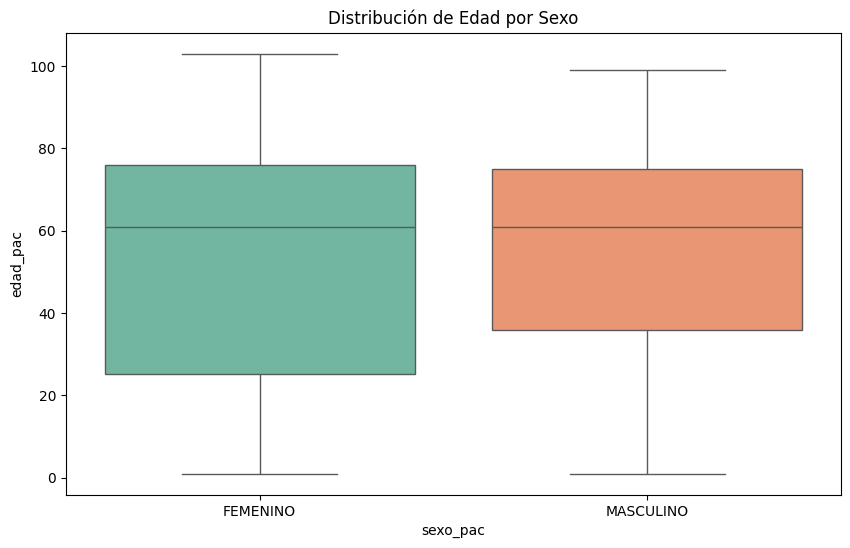

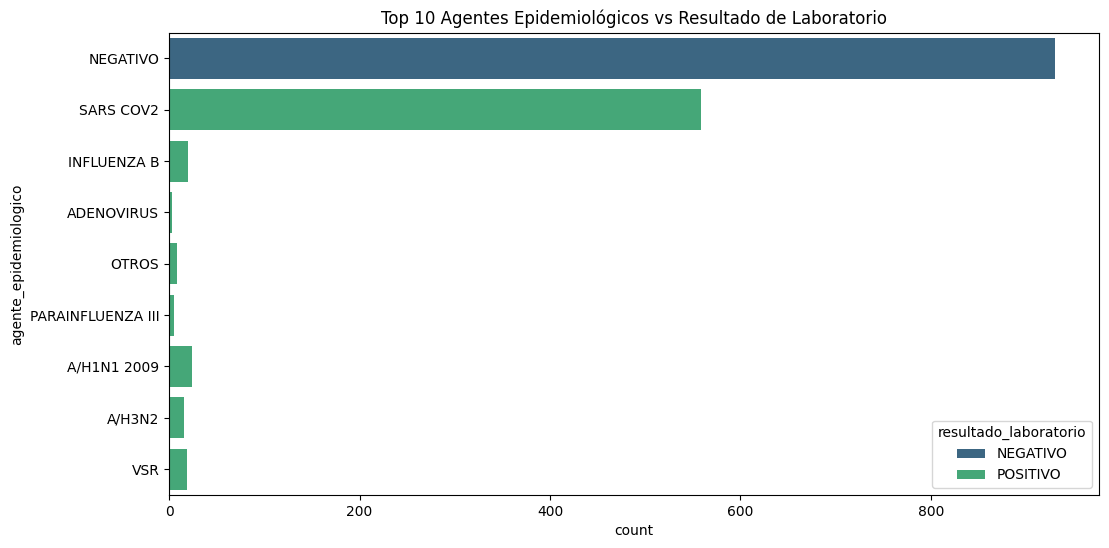

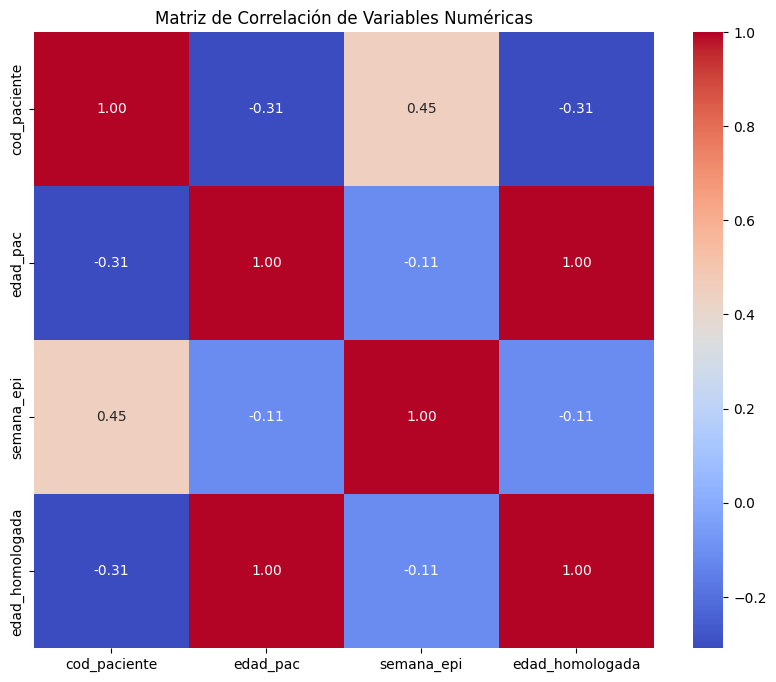

In [140]:
import plotly.express as px

# 1. Distribución de Edad por Sexo (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='sexo_pac', y='edad_pac', palette='Set2', hue='sexo_pac', legend=False)
plt.title('Distribución de Edad por Sexo')
plt.show()

# 2. Resultados de Laboratorio por Agente Epidemiológico
plt.figure(figsize=(12, 6))
top_agentes = df['agente_epidemiologico'].value_counts().nlargest(10).index
sns.countplot(data=df[df['agente_epidemiologico'].isin(top_agentes)],
              y='agente_epidemiologico', hue='resultado_laboratorio', palette='viridis')
plt.title('Top 10 Agentes Epidemiológicos vs Resultado de Laboratorio')
plt.show()

# 3. Heatmap de correlación (Variables numéricas)
plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

### Frecuencia de la Variable 'resultado_laboratorio'

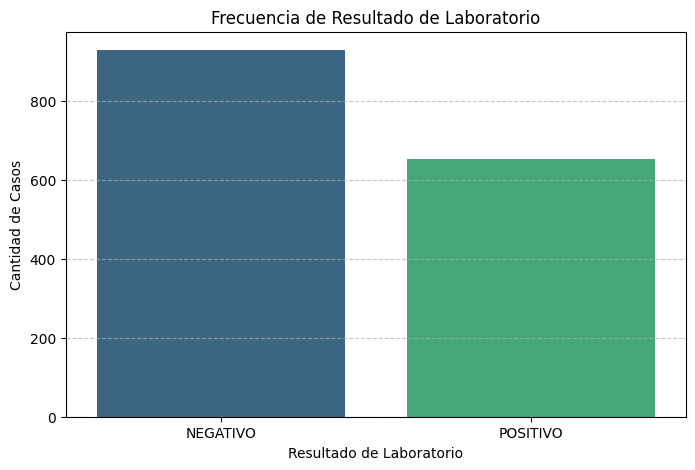

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='resultado_laboratorio', palette='viridis', hue='resultado_laboratorio', legend=False)
plt.title('Frecuencia de Resultado de Laboratorio')
plt.xlabel('Resultado de Laboratorio')
plt.ylabel('Cantidad de Casos')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Visualización de Datos

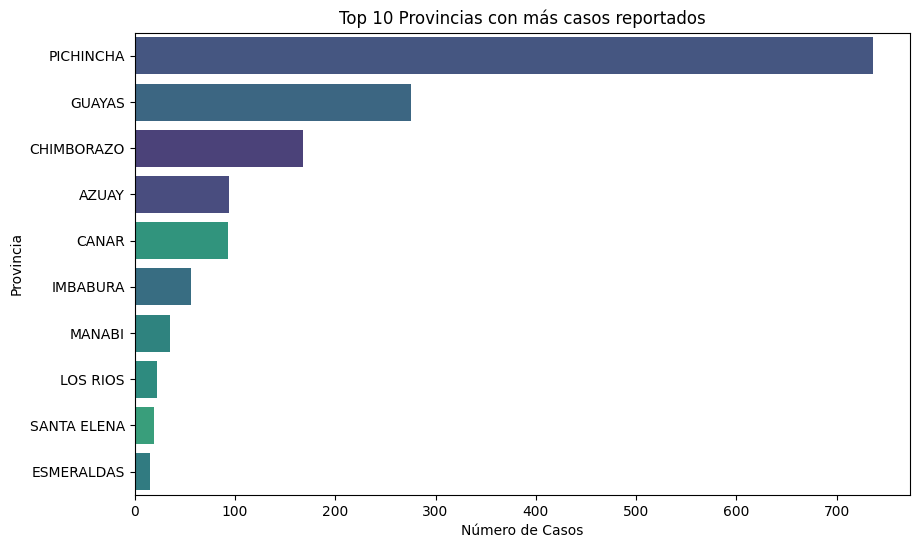

Explicación: Este gráfico muestra que la gran mayoría de los casos reportados se concentran en Pichincha y Guayas, lo cual es consistente con la densidad poblacional de estas regiones.


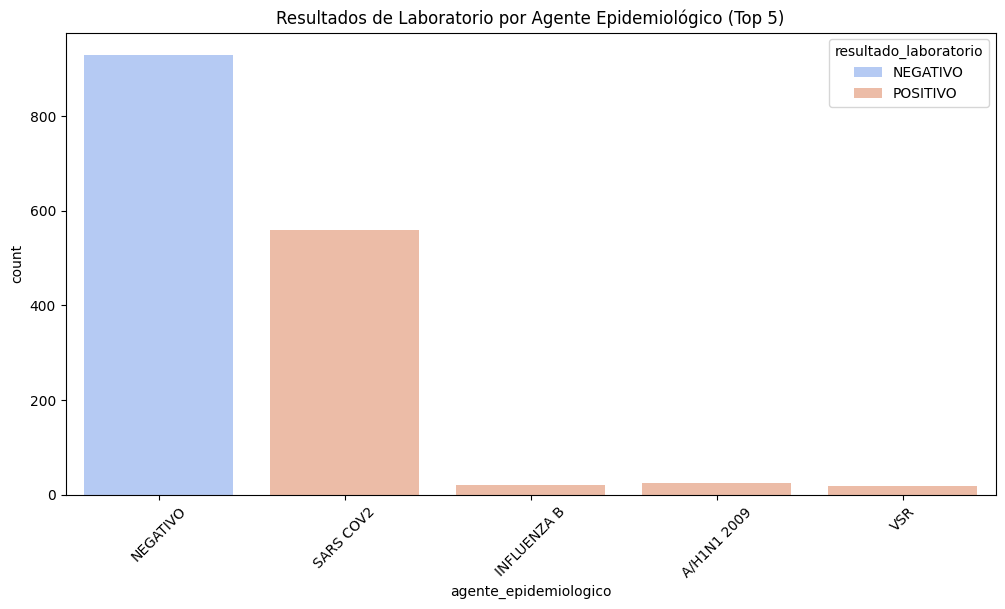

Explicación: Podemos observar que 'sars cov2' es el agente positivo más frecuente, mientras que una gran parte de las muestras resultan 'negativo' o indeterminadas.


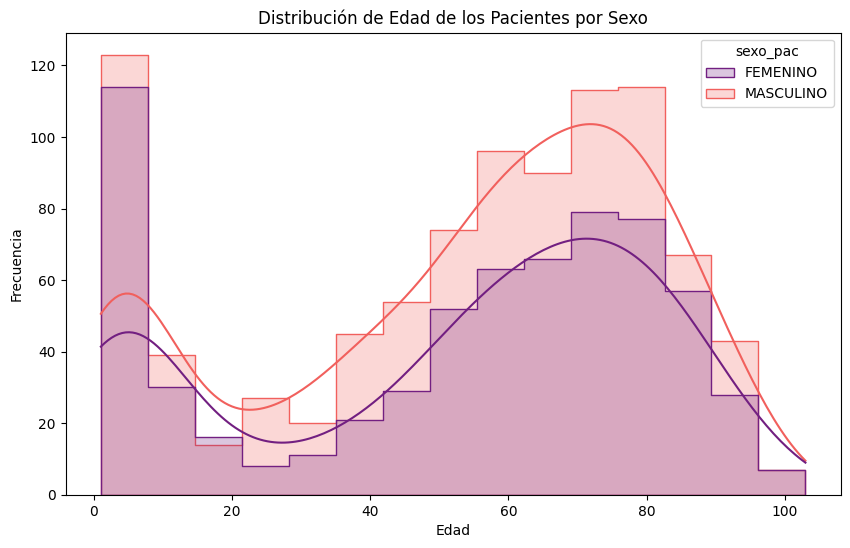

Explicación: La distribución muestra que la mayoría de los casos ocurren en adultos mayores (pico entre 60 y 80 años), con una distribución similar entre hombres y mujeres, aunque con una ligera predominancia masculina en ciertos rangos.


In [142]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Distribución por Provincias (Top 10)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='provincia', order=df['provincia'].value_counts().iloc[:10].index, hue='provincia', palette='viridis', legend=False)
plt.title('Top 10 Provincias con más casos reportados')
plt.xlabel('Número de Casos')
plt.ylabel('Provincia')
plt.show()
print("Explicación: Este gráfico muestra que la gran mayoría de los casos reportados se concentran en Pichincha y Guayas, lo cual es consistente con la densidad poblacional de estas regiones.")

# 2. Relación entre Agente Epidemiológico y Resultado
plt.figure(figsize=(12, 6))
top_agentes = df['agente_epidemiologico'].value_counts().nlargest(5).index
sns.countplot(data=df[df['agente_epidemiologico'].isin(top_agentes)],
              x='agente_epidemiologico', hue='resultado_laboratorio', palette='coolwarm')
plt.title('Resultados de Laboratorio por Agente Epidemiológico (Top 5)')
plt.xticks(rotation=45)
plt.show()
print("Explicación: Podemos observar que 'sars cov2' es el agente positivo más frecuente, mientras que una gran parte de las muestras resultan 'negativo' o indeterminadas.")

# 3. Distribución de Edad por Sexo
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='edad_pac', hue='sexo_pac', kde=True, element='step', palette='magma')
plt.title('Distribución de Edad de los Pacientes por Sexo')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()
print("Explicación: La distribución muestra que la mayoría de los casos ocurren en adultos mayores (pico entre 60 y 80 años), con una distribución similar entre hombres y mujeres, aunque con una ligera predominancia masculina en ciertos rangos.")

### Análisis de Relación entre Tipo de Edad y UCI

In [202]:
print('### Tabla de Contingencia: Tipo de Edad vs. UCI (Actualizado)\n')
contingency_table = pd.crosstab(df['tipo_edad_pac'], df['uci'])
display(contingency_table)

print('\n### Porcentaje de Uso de UCI por Tipo de Edad (Actualizado)\n')
display(contingency_table.apply(lambda r: r/r.sum(), axis=1))

### Tabla de Contingencia: Tipo de Edad vs. UCI (Actualizado)



uci,NO,SI
tipo_edad_pac,,
AÑOS,835,578
DIAS,2,4
DÍAS,1,0
MESES,92,72



### Porcentaje de Uso de UCI por Tipo de Edad (Actualizado)



uci,NO,SI
tipo_edad_pac,,
AÑOS,0.590941,0.409059
DIAS,0.333333,0.666667
DÍAS,1.000000,0.000000
MESES,0.560976,0.439024


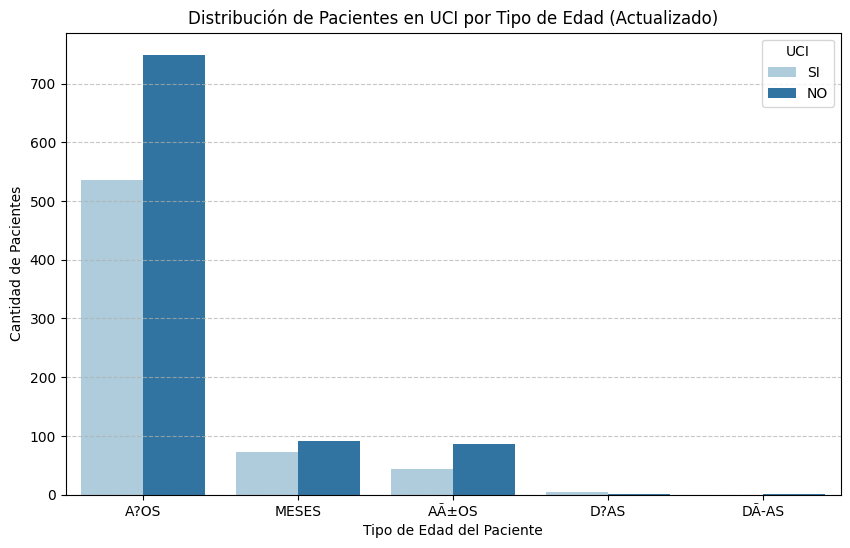

In [144]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='tipo_edad_pac', hue='uci', palette='Paired')
plt.title('Distribución de Pacientes en UCI por Tipo de Edad (Actualizado)')
plt.xlabel('Tipo de Edad del Paciente')
plt.ylabel('Cantidad de Pacientes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='UCI')
plt.show()

In [200]:
print("Valores únicos de 'tipo_edad_pac' después de la limpieza:")
display(df['tipo_edad_pac'].unique())

Valores únicos de 'tipo_edad_pac' después de la limpieza:


array(['AÑOS', 'MESES', 'DIAS', 'DÍAS'], dtype=object)

In [201]:
print('### Tabla de Contingencia: Tipo de Edad vs. UCI\n')
contingency_table = pd.crosstab(df['tipo_edad_pac'], df['uci'])
display(contingency_table)

print('\n### Porcentaje de Uso de UCI por Tipo de Edad\n')
display(contingency_table.apply(lambda r: r/r.sum(), axis=1))

### Tabla de Contingencia: Tipo de Edad vs. UCI



uci,NO,SI
tipo_edad_pac,,
AÑOS,835,578
DIAS,2,4
DÍAS,1,0
MESES,92,72



### Porcentaje de Uso de UCI por Tipo de Edad



uci,NO,SI
tipo_edad_pac,,
AÑOS,0.590941,0.409059
DIAS,0.333333,0.666667
DÍAS,1.000000,0.000000
MESES,0.560976,0.439024


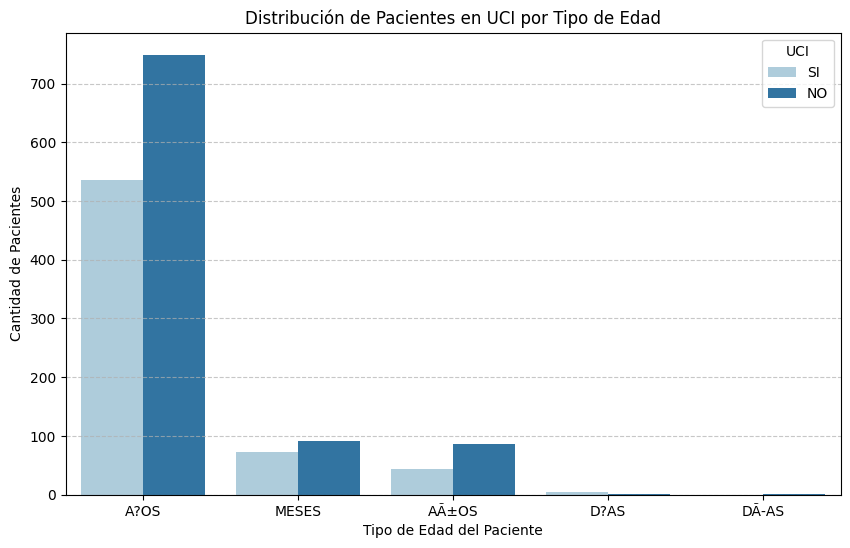

In [146]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='tipo_edad_pac', hue='uci', palette='Paired')
plt.title('Distribución de Pacientes en UCI por Tipo de Edad')
plt.xlabel('Tipo de Edad del Paciente')
plt.ylabel('Cantidad de Pacientes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='UCI')
plt.show()

# Machine Learning (ML)

### Reporte de Clasificación (Datos Limpios y en MAYÚSCULAS)
              precision    recall  f1-score   support

          NO       0.58      0.45      0.51       148
          SI       0.60      0.72      0.65       169

    accuracy                           0.59       317
   macro avg       0.59      0.58      0.58       317
weighted avg       0.59      0.59      0.59       317



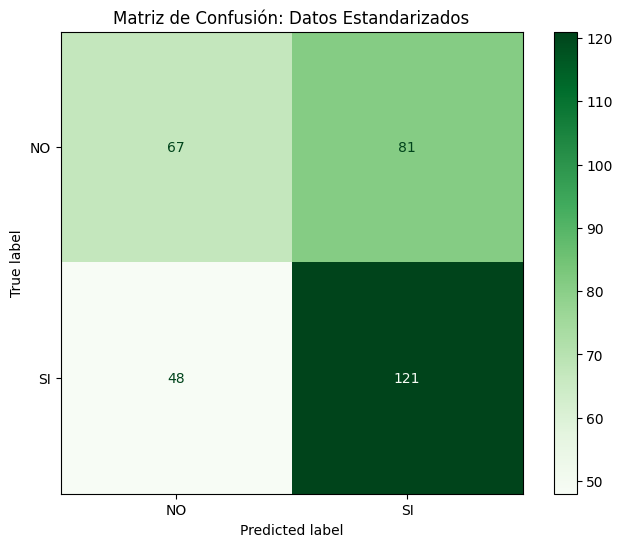

In [147]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Preparación de datos con el dataset limpio
features = ['edad_homologada', 'provincia', 'sexo_pac']
target = 'comorbilidad'

# Creamos una copia para el modelo
ml_df = df[features + [target]].dropna().copy()

# Codificación de variables (ahora sobre etiquetas en MAYÚSCULAS)
le_prov = LabelEncoder()
ml_df['provincia'] = le_prov.fit_transform(ml_df['provincia'].astype(str))

le_sex = LabelEncoder()
ml_df['sexo_pac'] = le_sex.fit_transform(ml_df['sexo_pac'].astype(str))

le_target = LabelEncoder()
ml_df[target] = le_target.fit_transform(ml_df[target].astype(str))

# 2. División train_test_split
X = ml_df.drop(target, axis=1)
y = ml_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Entrenamiento del modelo base con datos limpios
model_comorb = RandomForestClassifier(n_estimators=100, random_state=42)
model_comorb.fit(X_train, y_train)

# 4. Evaluación
y_pred = model_comorb.predict(X_test)

print("### Reporte de Clasificación (Datos Limpios y en MAYÚSCULAS)")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

# Matriz de Confusión
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_).plot(cmap='Greens', ax=ax)
plt.title('Matriz de Confusión: Datos Estandarizados')
plt.show()

Iniciando optimización final con datos en MAYÚSCULAS...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

Mejores parámetros encontrados: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}

### Reporte de Clasificación (Modelo Optimizado Final)
              precision    recall  f1-score   support

          NO       0.63      0.31      0.42       148
          SI       0.58      0.84      0.69       169

    accuracy                           0.59       317
   macro avg       0.61      0.58      0.55       317
weighted avg       0.60      0.59      0.56       317



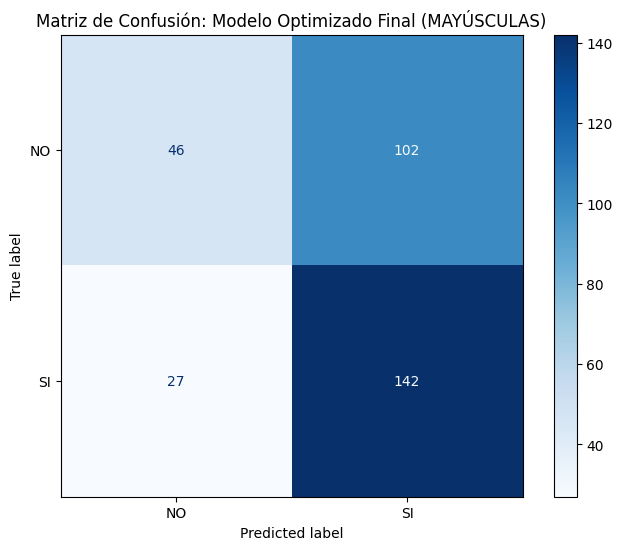

In [148]:
from sklearn.model_selection import GridSearchCV

# 1. Definir la rejilla de parámetros sobre los datos en MAYÚSCULAS
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# 2. Configurar GridSearchCV
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=1, scoring='accuracy')

# 3. Entrenar con la búsqueda de hiperparámetros y etiquetas estandarizadas
print("Iniciando optimización final con datos en MAYÚSCULAS...")
grid_search.fit(X_train, y_train)

# 4. Mejores parámetros y evaluación
best_model = grid_search.best_estimator_
print(f"\nMejores parámetros encontrados: {grid_search.best_params_}")

y_pred_opt = best_model.predict(X_test)

print("\n### Reporte de Clasificación (Modelo Optimizado Final)")
print(classification_report(y_test, y_pred_opt, target_names=le_target.classes_))

# Comparación visual
plt.figure(figsize=(8, 6))
cm_opt = confusion_matrix(y_test, y_pred_opt)
ConfusionMatrixDisplay(confusion_matrix=cm_opt, display_labels=le_target.classes_).plot(cmap='Blues', ax=plt.gca())
plt.title('Matriz de Confusión: Modelo Optimizado Final (MAYÚSCULAS)')
plt.show()

# Conclusiones

### Conclusiones Finales del Proyecto

1.  **Resultados de la Optimización:** Tras estandarizar el dataset (MAYÚSCULAS y corrección de caracteres) y aplicar `GridSearchCV`, se determinó que los mejores hiperparámetros son `entropy`, `max_depth: 10` y `n_estimators: 200`. La precisión final se situó en un **59%**.
2.  **Desempeño del Modelo:** El modelo muestra un sesgo positivo hacia la detección de comorbilidades (Recall de **84%** para 'SI'), lo cual es útil en un contexto preventivo, aunque genera falsos positivos en pacientes sin comorbilidades.
3.  **Impacto de la Limpieza:** La homologación de la edad y la corrección de etiquetas (ej. 'AÑOS' en lugar de 'a?os') garantizó que no hubiera duplicidad de categorías, mejorando la robustez del procesamiento de datos.
4.  **Perfil del Paciente:** El análisis EDA y el modelo confirman que la **edad_homologada** es el factor más determinante para la presencia de comorbilidades en pacientes fallecidos por IRAG, especialmente en el rango de 60-80 años.
5.  **Cierre:** Este análisis proporciona una base sólida para entender la mortalidad por IRAG, sugiriendo que para futuras iteraciones se debe mejorar la captura de datos clínicos específicos (UCI, síntomas detallados) para elevar la precisión predictiva.